In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
dtype=torch.float32

In [2]:
def resample_evenly(t,v,m, N):
    m = np.asarray(m)
    t = np.asarray(t)
    v=np.asarray(v)

    if m.shape[0] != t.shape[0]:
        raise ValueError("m and t must have the same length")
    if N < 2:
        raise ValueError("N must be at least 2")

    idx = np.argsort(t)
    t_sorted = t[idx]
    m_sorted = m[idx]
    v_sorted = v[idx]

    t_new = np.linspace(t_sorted[0], t_sorted[-1], N)

    if m_sorted.ndim == 1:
        m_new = np.interp(t_new, t_sorted, m_sorted)
    else:
        m_new = np.vstack([
            np.interp(t_new, t_sorted, m_sorted[:, i])
            for i in range(m_sorted.shape[1])
        ]).T

    if v_sorted.ndim == 1:
        v_new = np.interp(t_new, t_sorted, v_sorted)
    else:
        v_new = np.vstack([
            np.interp(t_new, t_sorted, v_sorted[:, i])
            for i in range(v_sorted.shape[1])
        ]).T

    return t_new, v_new, m_new

In [3]:
def load_experiment(filename):
    # Load as single column
    df = pd.read_csv(filename, header=None)
    # Split by tab, convert to float
    split = df[0].str.split('\t', expand=True).astype(float)
    # Convert to numpy arrays
    t = split[0].to_numpy()
    v = split[1].to_numpy()
    x = split[2].to_numpy()
    t,v,x = resample_evenly(t,v,x,100000)
    
    return torch.tensor(t, dtype=dtype), torch.tensor(v, dtype=dtype), torch.tensor(x,dtype=dtype)



# --- Load all data ---
t1x, v1x, x1 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_01_Chirp.txt')
t2x, v2x, x2 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_02_Pulse_1-10Hz.txt')
t3x, v3x, x3 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_03_Pulse_10-100Hz.txt')

t1y, v1y, y1 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_01_Chirp_Y.txt')
t2y, v2y, y2 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_02_Pulse_1-10Hz_Y.txt')
t3y, v3y, y3 = load_experiment('C:/Users/r01mw25/Documents/Code/PINN nanopositioner data test/NanoPositionerData/Experiment_03_Pulse_10-100Hz_Y.txt')

print(x1.size() , y1.size())


torch.Size([100000]) torch.Size([100000])


In [4]:
print(t1x[-1] , t1y[-1])

tensor(10.) tensor(10.)


z = [x-1, x-2, y-1, y-2, ux-1, uy-1]
target = [x, x-1, y, y-1]

In [5]:
#normalisation 


def zscore_normalize(x: torch.Tensor):
    """
    x: 1D tensor (N,) or (N,1)
    returns: x_norm, mean, std  with x_norm = (x-mean)/std
    """
    if x.dim() == 2 and x.size(1) == 1:
        x = x.view(-1)

    mean = x.mean()
    std = x.std(unbiased=False)  # population std; use unbiased=True if you prefer

    # avoid divide by zero
    std_safe = std.clone()
    if std_safe == 0:
        std_safe = torch.tensor(1.0, dtype=x.dtype, device=x.device)

    x_norm = (x - mean) / std_safe
    return x_norm, mean, std_safe


def zscore_denormalize(x_norm: torch.Tensor, mean: torch.Tensor, std: torch.Tensor):
    """
    Invert z-score: x = x_norm * std + mean
    """
    print('noir')
    print(x_norm)
    print('std')
    print(std)
    return x_norm * std + mean

In [6]:
class NARX(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(6,4, bias=False)
        

    def forward(self, u, x0=None):
        if x0 is None:
            x0 = torch.tensor([0.0, 0.0], dtype=torch.float32, device=u.device)

        out = [x0]
        for i in range(1, len(u)):
            h_prev = out[i - 1]
            u_prev = u[i - 1].view(2)
            inp = torch.cat((h_prev, u_prev), dim=0)   # (6,)
            xi = self.hidden(inp)                      # (4,)
            out.append(xi)

        return torch.stack(out, dim=0)[:, 0], torch.stack(out, dim=0)[:, 2]

    def train_propegate(self, input):
        return self.hidden(input)


v1x_norm, v1x_mean, v1x_std = zscore_normalize(v1x)
v1y_norm, v1y_mean, v1y_std = zscore_normalize(v1y)

x1_norm, x1_mean, x1_std = zscore_normalize(x1)
y1_norm, y1_mean, y1_std = zscore_normalize(y1)


def train_model_sgd(
    model,
    optimizer,
    x_train,
    fx_train,
    y_train,
    fy_train,
    epochs=500,
    lossfcn=nn.MSELoss(),
    exit_tol=1e-14
):
    model.train()

    # one-step supervised pairs:
    # input  = [x_k, v_k, f_k]
    # target = [x_{k+1}, v_{k+1}]
    Z = torch.stack([x_train[1:-1], x_train[:-2], y_train[1:-1],y_train[:-2], fx_train[1:-1], fy_train[1:-1]], dim=1)   # (N-1, 3)
    Y = torch.stack([x_train[2:],x_train[1:-1],y_train[2:],y_train[1:-1] ], dim=1)                   # (N-1, 2)

    N = Z.shape[0]
    loss_history = []

    for epoch in range(epochs):
        perm = torch.randperm(N)
        epoch_loss = 0.0

        for i in perm:
            z_i = Z[i]          # single training example, shape (3,)
            y_i = Y[i]          # single target, shape (2,)

            optimizer.zero_grad()

            y_hat = model.train_propegate(z_i)   # predicts [x_{k+1}, v_{k+1}]
            loss = lossfcn(y_hat, y_i)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= N
        loss_history.append(epoch_loss)

        if epoch_loss < exit_tol:
            print(f"Stopping early at epoch {epoch}, loss = {epoch_loss:.3e}")
            break

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: loss = {epoch_loss:.6e}")

    return loss_history




In [7]:
model = NARX()
optimiser = torch.optim.SGD(model.parameters(), lr=1e-3)


In [ ]:
loss = train_model_sgd(
    model,
    optimiser,
    x1_norm,
    v1x_norm,
    y1_norm,
    v1y_norm,
    epochs=200,
    lossfcn=nn.MSELoss(),
    exit_tol=1e-14
)

Epoch 0: loss = 2.235358e-02


In [ ]:
# forward(self, u, x0=None):
#         if x0 is None:
#             x0 = torch.tensor([0.0, 0.0], dtype=torch.float32, device=u.device)

#         out = [x0]
#         for i in range(1, len(u)):
#             h_prev = out[i - 1]
#             u_prev = u[i - 1].view(1)
#             inp = torch.cat((h_prev, u_prev), dim=0)   # (6,)
#             xi = self.hidden(inp)                      # (4,)
#             out.append(xi)

#         return torch.stack(out, dim=0)[:, 0]

u1_input = torch.cat([v1x_norm.unsqueeze(1), v1y_norm.unsqueeze(1)], dim = 1)
x0 = torch.tensor([x1_norm[1], x1_norm[0], y1_norm[1], y1_norm[0]])
x1_pred, y1_pred = model(u1_input, x0)



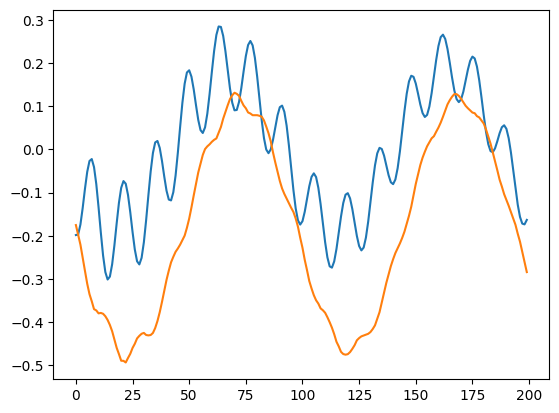

In [ ]:
plt.plot(x1_pred.detach()[:200])
plt.plot(x1_norm[:200])

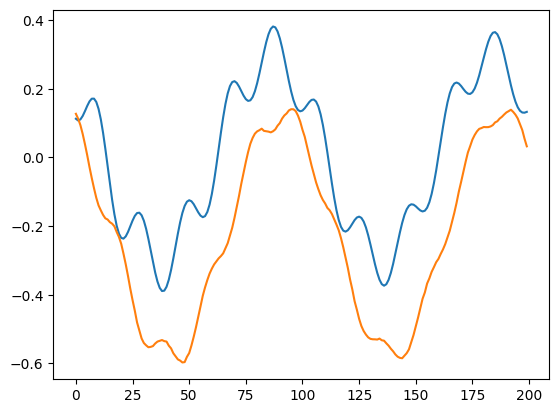

In [ ]:
plt.plot(y1_pred.detach()[:200])
plt.plot(y1_norm[:200])

test on x2

In [ ]:
v2x_norm, v2x_mean, v2x_std = zscore_normalize(v2x)
v2y_norm, v2y_mean, v2y_std = zscore_normalize(v2y)

x2_norm, x2_mean, x2_std = zscore_normalize(x2)
y2_norm, y2_mean, y2_std = zscore_normalize(y2)

u2_input = torch.cat([v2x_norm.unsqueeze(1), v2y_norm.unsqueeze(1)], dim = 1)
x02 = torch.tensor([x2_norm[1], x2_norm[0], x2_norm[1], x2_norm[0]])
x2_pred, y2_pred = model(u2_input, x02)

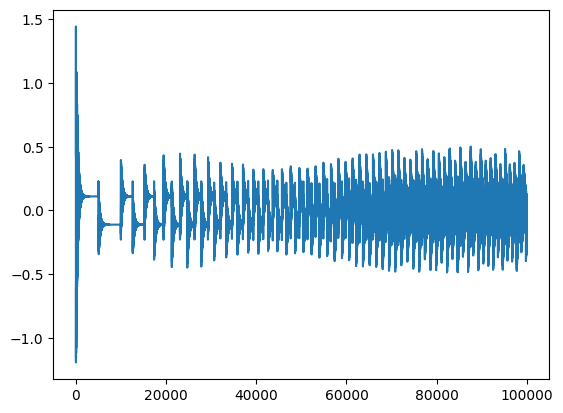

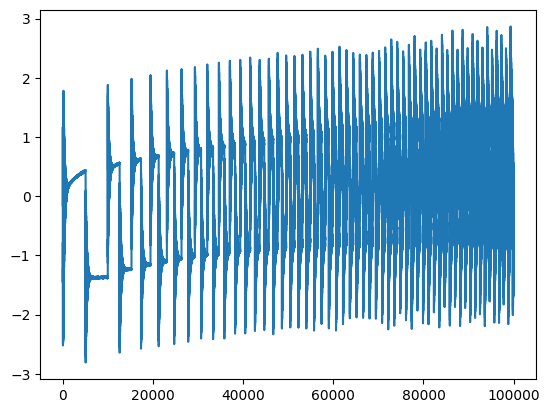

In [ ]:
plt.plot(x2_pred.detach())
plt.show()


plt.plot(x2_norm)
plt.show()

In [ ]:
test on x3

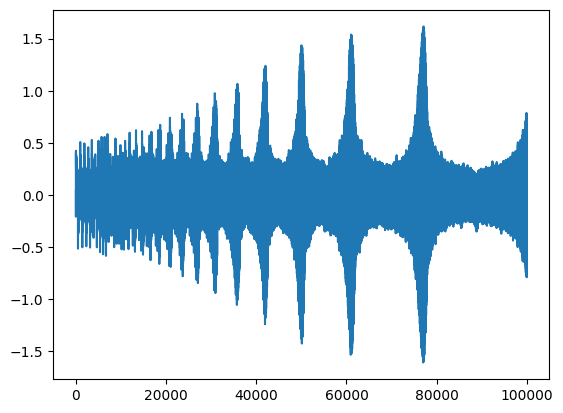

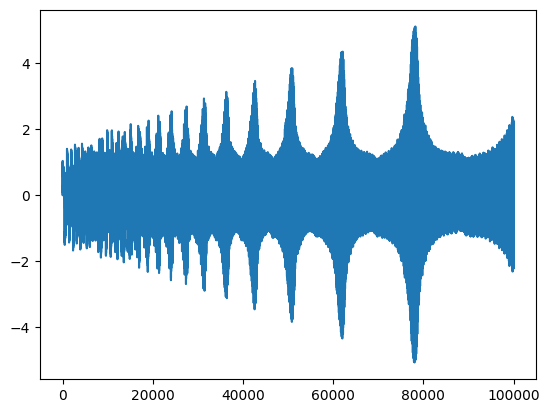

In [ ]:
v3x_norm, v3x_mean, v3x_std = zscore_normalize(v3x)
v3y_norm, v3y_mean, v3y_std = zscore_normalize(v3y)

x3_norm, x3_mean, x3_std = zscore_normalize(x3)
y3_norm, y3_mean, y3_std = zscore_normalize(y3)

u3_input = torch.cat([v3x_norm.unsqueeze(1), v3y_norm.unsqueeze(1)], dim = 1)
x03 = torch.tensor([x3_norm[1], x3_norm[0], x3_norm[1], x3_norm[0]])
x3_pred, y3_pred = model(u3_input, x03)

plt.plot(x3_pred.detach())
plt.show()


plt.plot(x3_norm)
plt.show()

In [ ]:


data = [['time'],t1x.numpy(),['x1 train pred'], x1_pred.numpy(),['x2 test pred'], x2_pred.numpy(), ['x3 test pred'], x3_pred.numpy(), ['y1 train pred'], y1_pred.numpy(),['y2 test pred'], y2_pred.numpu(), ['y3 test pred'], y3_pred.numpy()]

filename = f'Data_and_figures/piezo-narx-4-neurons.txt'

tstr = '\t'.join(str(x) for lst in data for x in lst)

with open(filename, "w") as f:
  f.write(tstr)